<a href="https://colab.research.google.com/github/iamkzntsv/self-supervised-learning-mri/blob/master/VAE_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import torch
import torch.nn as nn
import torch.distributions as dist
from torch.nn import functional as F
import matplotlib.pyplot as plt
import numpy as np

In [90]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [91]:
!pip install torch-summary

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [92]:
from torchsummary import summary

# Encoder

In [93]:
latent_dim = 2

In [94]:
class Encoder(nn.Module):

    def __init__(self, in_channels, latent_dim, dropout_rate):
        """
        :param in_channels: number of channels in the input shape
        :param latent_dim: size of latent space (int)
        :param dropout_rate: dropout probability (float)
        """
        super(Encoder, self).__init__()
        self.latent_dim = latent_dim
        self.dropout_rate = dropout_rate

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv2d(128, 16, kernel_size=1)
        self.fc1 = nn.Linear(256, 512)
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_log_var = nn.Linear(512, latent_dim)

    def encode(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.conv4(x)
        x = torch.relu(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = torch.relu(x)
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick
        :param mu:
        :param log_var:
        :return:
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)

        return mu + std * eps

    def forward(self, X):
        """
        Sample z from a distribution q
        :param X: input of shape (B, C, H, W)
        :return: 
          sample from the distribution q_zx
          a list containing mu and sigma vectors
        """
        mu, log_var = self.encode(X)
        z = self.reparameterize(mu, log_var)

        return [z, mu, log_var]

In [95]:
enc = Encoder(1, latent_dim, 0.2) # num_channels, latent_dim, dropout_prob
summary(enc, (1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 14, 14]          320
├─Conv2d: 1-2                            [-1, 64, 7, 7]            18,496
├─Conv2d: 1-3                            [-1, 128, 4, 4]           73,856
├─Conv2d: 1-4                            [-1, 16, 4, 4]            2,064
├─Linear: 1-5                            [-1, 512]                 131,584
├─Linear: 1-6                            [-1, 2]                   1,026
├─Linear: 1-7                            [-1, 2]                   1,026
Total params: 228,372
Trainable params: 228,372
Non-trainable params: 0
Total mult-adds (M): 2.31
Input size (MB): 0.00
Forward/backward pass size (MB): 0.09
Params size (MB): 0.87
Estimated Total Size (MB): 0.97


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 14, 14]          320
├─Conv2d: 1-2                            [-1, 64, 7, 7]            18,496
├─Conv2d: 1-3                            [-1, 128, 4, 4]           73,856
├─Conv2d: 1-4                            [-1, 16, 4, 4]            2,064
├─Linear: 1-5                            [-1, 512]                 131,584
├─Linear: 1-6                            [-1, 2]                   1,026
├─Linear: 1-7                            [-1, 2]                   1,026
Total params: 228,372
Trainable params: 228,372
Non-trainable params: 0
Total mult-adds (M): 2.31
Input size (MB): 0.00
Forward/backward pass size (MB): 0.09
Params size (MB): 0.87
Estimated Total Size (MB): 0.97

In [96]:
X = torch.randn(12, 1, 28, 28)
enc = Encoder(1, 2, 0.2)
z, mu, log_var = enc(X)
log_var.shape

torch.Size([12, 2])

# Decoder

In [97]:
class Decoder(nn.Module):

    def __init__(self, out_channels, latent_dim):
        super(Decoder, self).__init__()
        self.out_channels = out_channels
        self.latent_dim = latent_dim

        self.fc1 = nn.Linear(latent_dim, 256)
        self.fc2 = nn.Linear(256, 16*7*7)
        self.conv1 = nn.ConvTranspose2d(16, 128, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, z):
        x = self.fc1(z)
        x = self.fc2(x)
        x = x.reshape(-1, 16, 7, 7)
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.conv4(x)
        return torch.sigmoid(x)

In [98]:
dec = Decoder(1, latent_dim) # out_channels, latent_dim
summary(dec, (1, latent_dim))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 256]              768
├─Linear: 1-2                            [-1, 1, 784]              201,488
├─ConvTranspose2d: 1-3                   [-1, 128, 14, 14]         18,560
├─ConvTranspose2d: 1-4                   [-1, 64, 28, 28]          73,792
├─ConvTranspose2d: 1-5                   [-1, 32, 28, 28]          18,464
├─ConvTranspose2d: 1-6                   [-1, 1, 28, 28]           289
Total params: 313,361
Trainable params: 313,361
Non-trainable params: 0
Total mult-adds (M): 76.29
Input size (MB): 0.00
Forward/backward pass size (MB): 0.78
Params size (MB): 1.20
Estimated Total Size (MB): 1.97


Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 256]              768
├─Linear: 1-2                            [-1, 1, 784]              201,488
├─ConvTranspose2d: 1-3                   [-1, 128, 14, 14]         18,560
├─ConvTranspose2d: 1-4                   [-1, 64, 28, 28]          73,792
├─ConvTranspose2d: 1-5                   [-1, 32, 28, 28]          18,464
├─ConvTranspose2d: 1-6                   [-1, 1, 28, 28]           289
Total params: 313,361
Trainable params: 313,361
Non-trainable params: 0
Total mult-adds (M): 76.29
Input size (MB): 0.00
Forward/backward pass size (MB): 0.78
Params size (MB): 1.20
Estimated Total Size (MB): 1.97

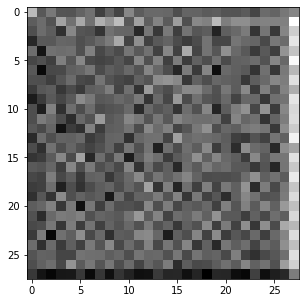

In [99]:
z = torch.randn(1, latent_dim).to(device)
X_hat = dec(z).squeeze()

X_hat = dec(z).squeeze().cpu().detach().numpy()
plt.rcParams["figure.figsize"] = (5,5)
plt.imshow(X_hat, cmap='gray')
plt.show()

# VAE

In [100]:
class VAE(nn.Module):

    def __init__(self, in_channels, latent_dim, out_channels, dropout_rate):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(in_channels, latent_dim, dropout_rate)
        self.decoder = Decoder(out_channels, latent_dim)

    def encode(self, X):
        z,_,_ = self.encoder(X)
        return z

    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, X):
        z, mu, log_var = self.encoder(X)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

In [101]:
vae = VAE(1, 2, 1, 0.2) # in, latent, out, dropout
X = torch.rand(10, 1, 28, 28) # (B, C, H, W)

In [102]:
# Get sample from the latent distribution
z = vae.encode(X)
print(f"z size: {z.size()}")

# Run the through the decoder
x_hat = vae.decode(z)
print(f"x_hat size: {x_hat.size()}")

z size: torch.Size([10, 2])
x_hat size: torch.Size([10, 1, 28, 28])


# Loss

## KL Div

In [103]:
def kl_divergence(mu, log_var):
    """
    Compute the KL divergence between given distribution q(z|x) and standard normal distribution
    :param mu: mean vector produced by the encoder, tensor of shape (B, latent_dim)
    :param log_var: log sigma vector produced by the encoder, tensor of shape (B, latent_dim)
    :return: KL divergence between q(z|x) and p(z), where p(z)~N(0,I).
    """
    kl = 0.5 * torch.sum((torch.exp(log_var) + torch.square(mu) - 1 - log_var), dim=-1)

    return torch.mean(kl)

In [104]:
# Test case 1: Standard Normal distribution
mu1 = torch.unsqueeze(torch.zeros(5), 0)
log_var1 = torch.log(torch.unsqueeze(torch.ones(5), 0))

# Test case 2: Normal distribution with randn noise 
mu2 = torch.unsqueeze(torch.zeros(5), 0)
log_var2 = torch.log(torch.unsqueeze(torch.ones(5), 0)) + torch.randn(1,5)

# Test case 2: Normal distribution with shifted mean and randn noise
mu3 = torch.unsqueeze(torch.zeros(5), 0) + 2
log_var3 = torch.log(torch.unsqueeze(torch.ones(5), 0)) + torch.randn(1,5)

print(kl_divergence(mu1, log_var1))
print(kl_divergence(mu2, log_var2))
print(kl_divergence(mu3, log_var3))

tensor(0.)
tensor(3.2656)
tensor(10.7434)


## Reconstruction

Normal Distribution pdf:

$$p(x | \mu, \sigma) = \frac{1}{\sigma \sqrt{2 \pi}} \exp{\bigg(-\frac{1}{2}\frac{(x - \mu)^2}{\sigma^2}}\bigg)$$

Likelihood for $Y = {y_{1}, y_{1},... y_{n}}$.

\begin{align}
\mathcal{L}(\theta|Y) 
&= \Pi_{i=1}^n \Bigl[\frac{1}{\sigma_{\theta}(x_{i}) \sqrt{2 \pi}} \exp{\bigg(-\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}}\bigg)\Bigr] \\
&= \sum_{i=1}^n log \Bigl[\frac{1}{\sigma_{\theta}(x_{i}) \sqrt{2 \pi}} \exp{\bigg(-\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}}\bigg) \Bigr] \\
&= \sum_{i=1}^n \Bigl[-\frac{1}{2}\log2\pi- \log\sigma_{\theta}(x_{i}) -\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}\Bigr] \\
\end{align}

Where:

$\qquad x_{i}$ is the input data.

$\qquad y_{i}$ is the true value of the dependent variable.

$\qquad \mu_{\theta}(x_{i})$ is the output of the model.

$\qquad \sigma(x_{i})$ is the standart deviation of the data sample.

Optimal parameters are then given by:

\begin{align}
\underset{\theta}{\mathrm{argmax}}\ \mathcal{L}(\theta|Y) 
&= \underset{\theta}{\mathrm{argmax}}\ \sum_{i=1}^n \Bigl[-\frac{1}{2}\log2\pi- \log \sigma_{\theta}(x_{i}) -\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}\Bigr] \\
&= \underset{\theta}{\mathrm{argmin}}\ \sum_{i=1}^n \Bigl[\log\sigma_{\theta}(x_{i}) +\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}\Bigr] \\
\end{align}


In [105]:
import torch.nn.functional as F

In [106]:
def reconstruction_loss(X, X_hat, scale_var=0.001):
    """
    Compute the reconstruction loss
    :param X:
    :param X_hat:
    :return:
    """
    X = torch.reshape(X, (X.shape[0], -1))
    X_hat = torch.reshape(X_hat, (X_hat.shape[0], -1))
    var = torch.ones(X.size()).to(device) * scale_var

    criterion = nn.GaussianNLLLoss(reduction='none').to(device)
    return torch.mean(torch.sum(criterion(X, X_hat, var), dim=-1))

In [107]:
# Same tensor
X = torch.randn(5, 1, 100, 100).to(device)
X_hat = X.clone().detach()
loss = reconstruction_loss(X_hat, X_hat)
print(loss)

tensor(-34538.7773, device='cuda:0')


In [108]:
# Different tensors
X = torch.rand(5, 1, 100, 100).to(device)
X_hat = torch.rand(5, 1, 100, 100).to(device)
loss = reconstruction_loss(X, X_hat)
print(loss)

tensor(805593.5000, device='cuda:0')


## Total Loss

In [109]:
class Loss_VAE(nn.Module):

    def __init__(self):
        super(Loss_VAE, self).__init__()

    def forward(self, X_hat, X, mu, log_var):
        loss = self.kl_divergence(mu, log_var) + self.reconstruction_loss(X_hat, X)
        return loss
    

    def kl_divergence(self, mu, log_var):
        """
        Compute the KL divergence between given distribution q(z|x) and standard normal distribution
        :param mu: mean vector produced by the encoder, tensor of shape (B, latent_dim)
        :param log_var: log sigma vector produced by the encoder, tensor of shape (B, latent_dim)
        :return: KL divergence between q(z|x) and p(z), where p(z)~N(0,I).
        """
        kl = 0.5 * torch.sum((torch.exp(log_var) + torch.square(mu) - 1 - log_var), -1)
        return torch.mean(kl)

    def reconstruction_loss(self, X_hat, X, scale_var=0.001):
        """
        Compute the reconstruction loss
        :param X: input data
        :param X_hat: output of the decoder, considered as the mean
        :param scale_var: a small number for scaling variance
        :return: reconstruction
        """
        X = torch.reshape(X, (X.shape[0], -1))
        X_hat = torch.reshape(X_hat, (X_hat.shape[0], -1))
        var = torch.ones(X.size()).to(device) * scale_var

        criterion = nn.GaussianNLLLoss(reduction='none').to(device)
        return torch.mean(torch.sum(criterion(X, X_hat, var), dim=-1))

# Training

In [110]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.utils import make_grid
from torchvision.transforms import Compose
from torchvision.transforms import ToTensor, Resize
from torch.utils.data import DataLoader
import itertools

In [111]:
transform = Compose([ToTensor()])
mnist_dataset = MNIST(root="data/", download=True, transform=transform)
train_loader = DataLoader(mnist_dataset, batch_size=100, shuffle=True)
num_batches = int(len(mnist_dataset) / 64)

In [114]:
num_in, latent_dim, num_out,  = 1, 4, 1
vae = VAE(num_in, latent_dim, num_out, 0.2).to(device)

optimizer = torch.optim.Adam(vae.parameters())

loss_function = Loss_VAE()

In [115]:
def train(epoch):
    vae.train()
    train_loss = 0
    for batch_idx, (X, _) in enumerate(train_loader):
        X = X.to(device)
        optimizer.zero_grad()
        
        X_hat, mu, log_var = vae(X)
        loss = loss_function(X_hat, X, mu, log_var)
        
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print('Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(X), len(train_loader.dataset), loss.item() / len(X)))
    print('====> Epoch: {} Average loss: {:.4f}'.format(epoch, train_loss / len(train_loader.dataset)))

for epoch in range(1, 10):
    train(epoch)

Epoch: 1 [0/60000]	Loss: 915.913359
Epoch: 1 [10000/60000]	Loss: 215.085566
Epoch: 1 [20000/60000]	Loss: 152.417432
Epoch: 1 [30000/60000]	Loss: 121.785957
Epoch: 1 [40000/60000]	Loss: 117.309775
Epoch: 1 [50000/60000]	Loss: 109.576289
====> Epoch: 1 Average loss: 155.1279
Epoch: 2 [0/60000]	Loss: 98.981006
Epoch: 2 [10000/60000]	Loss: 94.906230
Epoch: 2 [20000/60000]	Loss: 96.699141
Epoch: 2 [30000/60000]	Loss: 96.016846
Epoch: 2 [40000/60000]	Loss: 94.696768
Epoch: 2 [50000/60000]	Loss: 86.470996
====> Epoch: 2 Average loss: 96.9850
Epoch: 3 [0/60000]	Loss: 77.305259
Epoch: 3 [10000/60000]	Loss: 85.077588
Epoch: 3 [20000/60000]	Loss: 78.390996
Epoch: 3 [30000/60000]	Loss: 95.105166
Epoch: 3 [40000/60000]	Loss: 86.104687
Epoch: 3 [50000/60000]	Loss: 84.975781
====> Epoch: 3 Average loss: 88.2281
Epoch: 4 [0/60000]	Loss: 82.229297
Epoch: 4 [10000/60000]	Loss: 92.210605
Epoch: 4 [20000/60000]	Loss: 76.614561
Epoch: 4 [30000/60000]	Loss: 88.678477
Epoch: 4 [40000/60000]	Loss: 87.164648
E

In [116]:
from torchvision.utils import save_image

with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    sample = vae.decoder(z).to(device)  
    save_image(sample.view(64, 1, 28, 28), 'sample' + '.png')